In [19]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input

In [20]:
temp_model = tf.keras.models.load_model('best_brain_tumor_b3.h5')
class_names = ['glioma','meningioma','pituitary','notumor']

In [21]:
import tensorflow as tf 
from tensorflow.keras.applications import EfficientNetB3 
from tensorflow.keras import Model, Input 
inputs = Input(shape=(224,224,3)) 

base_model = EfficientNetB3( include_top=False, weights='imagenet', input_tensor=inputs ) 

x = base_model.output 
x = tf.keras.layers.GlobalAveragePooling2D()(x) 
x = tf.keras.layers.BatchNormalization()(x) 
x = tf.keras.layers.Dense(512, activation='relu')(x) 
x = tf.keras.layers.Dropout(0.5)(x) 
outputs = tf.keras.layers.Dense(4, activation='softmax')(x) 
model = Model(inputs, outputs)

In [22]:
model.set_weights(temp_model.get_weights())

In [23]:
def crop_center(img, crop_size=180):
    h, w, _ = img.shape
    startx = w//2 - crop_size//2
    starty = h//2 - crop_size//2
    return img[starty:starty+crop_size, startx:startx+crop_size]


def load_and_preprocess_image(img_path):
    original_img = cv2.imread(img_path)

    if original_img is None:
        raise ValueError(f"Image not found: {img_path}")

    # 🔥 KEEP ORIGINAL SAFE
    display_img = original_img.copy()

    # 🔥 Crop ONLY for model
    cropped_img = crop_center(original_img)

    cropped_img = cv2.resize(cropped_img, (224, 224))
    img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)

    img_array = preprocess_input(img_rgb.astype(np.float32))

    return display_img, img_rgb, np.expand_dims(img_array, axis=0)

In [24]:
def predict_image(model, img_array):
    preds = model.predict(img_array)
    class_index = np.argmax(preds[0])
    confidence = preds[0][class_index]
    
    return class_index, confidence

In [25]:
def suppress_edges(heatmap):
    h, w = heatmap.shape
    mask = np.zeros_like(heatmap)

    margin = int(0.15 * h)
    mask[margin:h-margin, margin:w-margin] = 1

    return heatmap * mask

In [26]:
def make_gradcam_heatmap(img_array, model, layer_name="block7a_project_bn"):

    layer = model.get_layer(layer_name)

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(0,1,2))

    cam = tf.reduce_sum(weights * conv_outputs[0], axis=-1)

    cam = tf.nn.relu(cam)
    cam /= (tf.reduce_max(cam) + 1e-8)

    return cam.numpy()

In [27]:
def mask_brain_region(heatmap, original_img):
    gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
    
    # Create brain mask (remove black background)
    _, brain_mask = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = heatmap * (brain_mask / 255)

    return heatmap

In [28]:
def draw_bounding_box(img, bbox):
    if bbox is None:
        return img

    x, y, w, h = bbox
    img_box = img.copy()

    cv2.rectangle(img_box, (x, y), (x+w, y+h), (0, 255, 0), 2)

    return img_box

In [29]:
def scale_bbox_to_original(bbox, original_shape, crop_size=180):
    if bbox is None:
        return None

    x, y, w, h = bbox
    H, W, _ = original_shape

    startx = W//2 - crop_size//2
    starty = H//2 - crop_size//2

    scale = crop_size / 224

    x = int(x * scale + startx)
    y = int(y * scale + starty)
    w = int(w * scale)
    h = int(h * scale)

    return x, y, w, h

In [30]:
def get_bounding_box(heatmap, threshold=0.5):

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)

    _, thresh = cv2.threshold(heatmap, int(255 * threshold), 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    # filter small regions
    contours = [c for c in contours if cv2.contourArea(c) > 200]

    if not contours:
        return None

    c = max(contours, key=cv2.contourArea)
    return cv2.boundingRect(c)

In [31]:
def overlay_heatmap(original_img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    superimposed_img = cv2.addWeighted(original_img, 1-alpha, heatmap, alpha, 0)
    
    return superimposed_img

In [32]:
def run_pipeline(img_path):

    original_img, img_rgb, img_array = load_and_preprocess_image(img_path)

    
    
    # Prediction
    class_index, confidence = predict_image(model, img_array)
    predicted_label = class_names[class_index]

    if confidence < 0.75:
        print("⚠️ Low confidence prediction - Grad-CAM may be unreliable")
        
    # Grad-CAM
    if predicted_label != "notumor":
        heatmap = make_gradcam_heatmap(img_array, model)
    else:
        heatmap = None
    
    heatmap = suppress_edges(heatmap)
    # heatmap = mask_brain_region(heatmap, original_img)

    # Bounding box
    bbox = get_bounding_box(heatmap, threshold=0.5)

    # 🔥 ADD THIS LINE (VERY IMPORTANT)
    bbox = scale_bbox_to_original(bbox, original_img.shape)
    
    boxed_img = draw_bounding_box(original_img, bbox)
    
    if heatmap is not None:
        heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
        heatmap_colored = cv2.applyColorMap(np.uint8(255*heatmap_resized), cv2.COLORMAP_JET)
        gradcam_img = cv2.addWeighted(original_img, 0.7, heatmap_colored, 0.3, 0)
    else:
        gradcam_img = original_img

    # Display
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(cv2.cvtColor(gradcam_img, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(boxed_img, cv2.COLOR_BGR2RGB))
    plt.title(f"{predicted_label} ({confidence*100:.2f}%)\nGrad-CAM shows important regions, not exact tumor")
    plt.axis('off')

    plt.show()

    return predicted_label, confidence

2026-04-20 04:28:01.386735: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-20 04:28:01.617963: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-20 04:28:02.861890: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-20 04:28:03.137063: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-20 04:28:03.407010: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
⚠️ Low confidence prediction - Grad-CAM may be unreliable


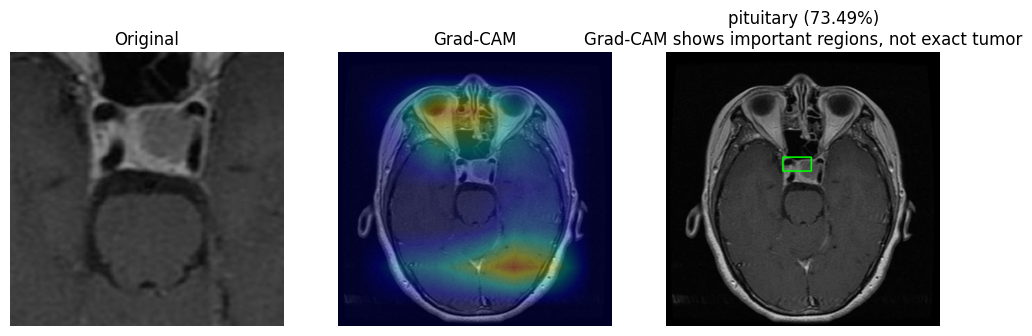

('pituitary', np.float32(0.7348563))

In [33]:
run_pipeline("dataset/Testing/pituitary/Te-pi_222.jpg")

# EfficientNetB0

In [78]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input

In [79]:
model = tf.keras.models.load_model('best_brain_tumor_b0.keras')

In [80]:
def crop_center(img, crop_size=180):
    h, w, _ = img.shape
    startx = w//2 - crop_size//2
    starty = h//2 - crop_size//2
    return img[starty:starty+crop_size, startx:startx+crop_size]


def load_and_preprocess_image(img_path):
    original_img = cv2.imread(img_path)

    if original_img is None:
        raise ValueError(f"Image not found: {img_path}")

    # 🔥 KEEP ORIGINAL SAFE
    display_img = original_img.copy()

    # 🔥 Crop ONLY for model
    cropped_img = crop_center(original_img)

    cropped_img = cv2.resize(cropped_img, (224, 224))
    img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)

    img_array = preprocess_input(img_rgb.astype(np.float32))

    return display_img, img_rgb, np.expand_dims(img_array, axis=0)

In [81]:
def predict_image(model, img_array):
    preds = model.predict(img_array)
    class_index = np.argmax(preds[0])
    confidence = preds[0][class_index]
    
    return class_index, confidence

In [82]:
def suppress_edges(heatmap):
    h, w = heatmap.shape
    mask = np.zeros_like(heatmap)

    margin = int(0.15 * h)
    mask[margin:h-margin, margin:w-margin] = 1

    return heatmap * mask

In [100]:
def make_gradcam_heatmap(img_array, model, layer_name="top_conv"):
    """
    Works with nested EfficientNet (model.get_layer('efficientnetb0'))
    """

    # 1) Split model into base (conv) and head (classifier)
    base_model = model.get_layer("efficientnetb0")

    # Build a model: input -> conv layer output
    conv_layer = base_model.get_layer(layer_name)
    conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=conv_layer.output
    )

    # Build classifier (the layers after base_model)
    classifier_input = tf.keras.Input(shape=conv_layer.output.shape[1:])
    x = classifier_input
    # model.layers = [InputLayer, efficientnetb0, GAP, BN, Dense, Dropout, Dense]
    for layer in model.layers[2:]:
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    img_tensor = tf.convert_to_tensor(img_array)

    # 2) Forward + gradients
    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_tensor)
        tape.watch(conv_outputs)

        predictions = classifier_model(conv_outputs)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    # 3) Grad-CAM
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam = tf.reduce_sum(weights * conv_outputs[0], axis=-1)

    cam = tf.nn.relu(cam)
    cam /= (tf.reduce_max(cam) + 1e-8)

    return cam.numpy()

In [84]:
def mask_brain_region(heatmap, original_img):
    gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
    
    # Create brain mask (remove black background)
    _, brain_mask = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = heatmap * (brain_mask / 255)

    return heatmap

In [85]:
def draw_bounding_box(img, bbox):
    if bbox is None:
        return img

    x, y, w, h = bbox
    img_box = img.copy()

    cv2.rectangle(img_box, (x, y), (x+w, y+h), (0, 255, 0), 2)

    return img_box

In [86]:
def scale_bbox_to_original(bbox, original_shape, crop_size=180):
    if bbox is None:
        return None

    x, y, w, h = bbox
    H, W, _ = original_shape

    startx = W//2 - crop_size//2
    starty = H//2 - crop_size//2

    scale = crop_size / 224

    x = int(x * scale + startx)
    y = int(y * scale + starty)
    w = int(w * scale)
    h = int(h * scale)

    return x, y, w, h

In [87]:
def get_bounding_box(heatmap, threshold=0.5):

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)

    _, thresh = cv2.threshold(heatmap, int(255 * threshold), 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    # filter small regions
    contours = [c for c in contours if cv2.contourArea(c) > 200]

    if not contours:
        return None

    c = max(contours, key=cv2.contourArea)
    return cv2.boundingRect(c)

In [88]:
def overlay_heatmap(original_img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    superimposed_img = cv2.addWeighted(original_img, 1-alpha, heatmap, alpha, 0)
    
    return superimposed_img

In [89]:
def run_pipeline(img_path):

    original_img, img_rgb, img_array = load_and_preprocess_image(img_path)

    
    
    # Prediction
    class_index, confidence = predict_image(model, img_array)
    predicted_label = class_names[class_index]
    
    if confidence < 0.75:
        print("⚠️ Low confidence prediction")
    
    # Grad-CAM
    if predicted_label != "notumor":
        img_array = tf.convert_to_tensor(img_array)
        heatmap = make_gradcam_heatmap(img_array, model)
        heatmap = suppress_edges(heatmap)
    else:
        heatmap = None
    
    # Bounding box
    if heatmap is not None:
        bbox = get_bounding_box(heatmap, threshold=0.5)
        bbox = scale_bbox_to_original(bbox, original_img.shape)
    else:
        bbox = None
    
    boxed_img = draw_bounding_box(original_img, bbox)
    
    if heatmap is not None:
        heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
        heatmap_colored = cv2.applyColorMap(np.uint8(255*heatmap_resized), cv2.COLORMAP_JET)
        gradcam_img = cv2.addWeighted(original_img, 0.7, heatmap_colored, 0.3, 0)
    else:
        gradcam_img = original_img

    # Display
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(cv2.cvtColor(gradcam_img, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(boxed_img, cv2.COLOR_BGR2RGB))
    plt.title(f"{predicted_label} ({confidence*100:.2f}%)\nGrad-CAM shows important regions, not exact tumor")
    plt.axis('off')

    plt.show()

    return predicted_label, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


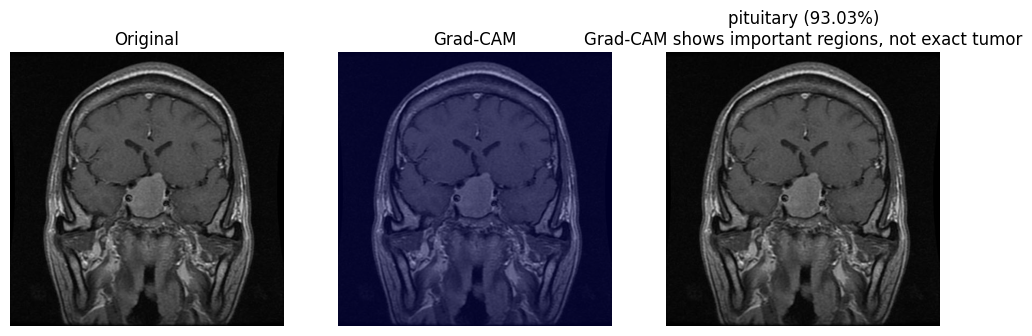

('pituitary', np.float32(0.9302655))

In [105]:
run_pipeline("dataset/Testing/pituitary/Te-pi_200.jpg")

In [97]:
for l in model.get_layer("efficientnetb0").layers:
    print(l.name)

input_layer
rescaling
normalization
rescaling_1
stem_conv_pad
stem_conv
stem_bn
stem_activation
block1a_dwconv
block1a_bn
block1a_activation
block1a_se_squeeze
block1a_se_reshape
block1a_se_reduce
block1a_se_expand
block1a_se_excite
block1a_project_conv
block1a_project_bn
block2a_expand_conv
block2a_expand_bn
block2a_expand_activation
block2a_dwconv_pad
block2a_dwconv
block2a_bn
block2a_activation
block2a_se_squeeze
block2a_se_reshape
block2a_se_reduce
block2a_se_expand
block2a_se_excite
block2a_project_conv
block2a_project_bn
block2b_expand_conv
block2b_expand_bn
block2b_expand_activation
block2b_dwconv
block2b_bn
block2b_activation
block2b_se_squeeze
block2b_se_reshape
block2b_se_reduce
block2b_se_expand
block2b_se_excite
block2b_project_conv
block2b_project_bn
block2b_drop
block2b_add
block3a_expand_conv
block3a_expand_bn
block3a_expand_activation
block3a_dwconv_pad
block3a_dwconv
block3a_bn
block3a_activation
block3a_se_squeeze
block3a_se_reshape
block3a_se_reduce
block3a_se_expand